In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import linear_kernel
from sklearn.metrics.pairwise import cosine_similarity
from ast import literal_eval
from surprise import Reader, Dataset, SVD
from surprise.model_selection import cross_validate


# データの用意

In [19]:
df_1 = pd.read_csv("/kaggle/input/tmdb-5000-movies/tmdb_5000_credits.csv")
df_2 = pd.read_csv("/kaggle/input/tmdb-5000-movies/tmdb_5000_movies.csv")
df_2 = df_2.drop(columns=['title'])


df_1.columns = ["id", "title", "cast", "crew"]
df = df_2.merge(df_1, on = "id")

In [20]:
df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,revenue,runtime,spoken_languages,status,tagline,vote_average,vote_count,title,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,7.2,11800,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",6.9,4500,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,6.3,4466,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,7.6,9106,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",6.1,2124,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


# Demographic Filtering（人口統計的フィルタリング）

In [21]:
#全ての映画評価投票の平均
C = df["vote_average"].mean()
C

6.092171559442015

In [22]:
#全ての映画の評価投票数上位90％
m = df["vote_count"].quantile(0.9)
m

1838.4000000000015

In [23]:
#映画のフィルタリング
q_movies = df.copy().loc[df["vote_count"] >= m]
q_movies.shape

(481, 22)

In [24]:
#IMDBの加重平均によるスコア算出と上位10タイトルの確認
def weighted_rating(x, m=m, C=C):
    v = x["vote_count"]
    R = x["vote_average"]
    return (v/(v+m)*R)+(m/(v+m)*C)

q_movies["score"] = q_movies.apply(weighted_rating, axis = 1)
q_movies = q_movies.sort_values("score", ascending = False)
q_movies[["title", "vote_count", "vote_average", "score"]].head(10)


,title,vote_count,vote_average,score
1881,The Shawshank Redemption,8205,8.5,8.059258
662,Fight Club,9413,8.3,7.939256
65,The Dark Knight,12002,8.2,7.920020
3232,Pulp Fiction,8428,8.3,7.904645
96,Inception,13752,8.1,7.863239
3337,The Godfather,5893,8.4,7.851236
95,Interstellar,10867,8.1,7.809479
809,Forrest Gump,7927,8.2,7.803188
329,The Lord of the Rings: The Return of the King,8064,8.1,7.727243
1990,The Empire Strikes Back,5879,8.2,7.697884


Text(0.5, 1.0, 'Popular Movies')

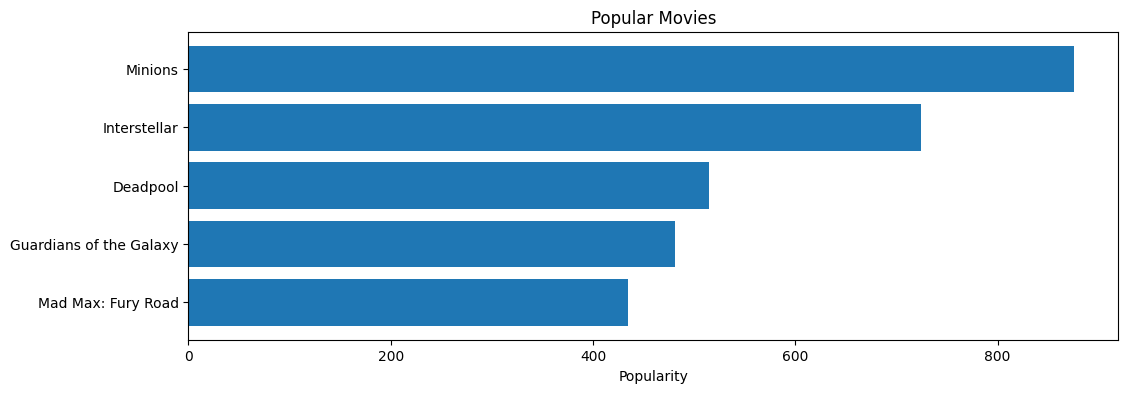

In [25]:
#人気度の順に可視化
pop = df.sort_values("popularity", ascending = False)
plt.figure(figsize = (12,4))

plt.barh(pop["title"].head(5), pop["popularity"].head(5), align = "center")
plt.gca().invert_yaxis()
plt.xlabel("Popularity")
plt.title("Popular Movies")

# Content Based Filtering （映画のコンテンツ類似度からおすすめ）

In [26]:
#各映画の概要
df["overview"].head(5)

0    In the 22nd century, a paraplegic Marine is di...
1    Captain Barbossa, long believed to be dead, ha...
2    A cryptic message from Bond’s past sends him o...
3    Following the death of District Attorney Harve...
4    John Carter is a war-weary, former military ca...
Name: overview, dtype: object

In [27]:
#TF-IDFベクトルを算出
tfidf = TfidfVectorizer(stop_words = "english")
df["overview"] = df["overview"].fillna("")
tfidf_matrix = tfidf.fit_transform(df["overview"])
tfidf_matrix.shape

(4803, 20978)

In [28]:
#コサイン類似度の算出
cos_sim = linear_kernel(tfidf_matrix, tfidf_matrix)

In [29]:
#各映画のインデックスを作成し、コサイン類似度から10個の映画をおすすめ
indices = pd.Series(df.index, index = df["title"]).drop_duplicates()

def get_recommendation(title, cos_sim = cos_sim):
    idx = indices[title]
    sim_scores = list(enumerate(cos_sim[idx]))
    sim_scores = sorted(sim_scores, key = lambda x: x[1], reverse = True)
    sim_scores = sim_scores[1:11]
    movie_indices = [i[0]for i in sim_scores]
    return df["title"].iloc[movie_indices]

get_recommendation("The Dark Knight Rises")

65                              The Dark Knight
299                              Batman Forever
428                              Batman Returns
1359                                     Batman
3854    Batman: The Dark Knight Returns, Part 2
119                               Batman Begins
2507                                  Slow Burn
9            Batman v Superman: Dawn of Justice
1181                                        JFK
210                              Batman & Robin
Name: title, dtype: object

# 協調フィルタリング

In [30]:
#データの用意
reader = Reader()
ratings = pd.read_csv("/kaggle/input/ratings-small/ratings_small.csv")
ratings.head()

,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205


In [31]:
#dfをsurprise形式に変換し、SVD（特異値分解）によるrating予測性能の確認
data = Dataset.load_from_df(ratings[["userId", "movieId", "rating"]], reader)
svd = SVD()
cross_validate(svd, data, measures = ["RMSE", "MAE"], cv = 5, verbose = True )

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8927  0.8935  0.8925  0.8983  0.9062  0.8967  0.0052  
MAE (testset)     0.6868  0.6880  0.6887  0.6906  0.6968  0.6902  0.0035  
Fit time          1.39    1.34    1.36    1.33    1.35    1.35    0.02    
Test time         0.12    0.14    0.10    0.10    0.22    0.14    0.05    


{'test_rmse': array([0.89265104, 0.8935415 , 0.89254845, 0.89833527, 0.90620897]),
 'test_mae': array([0.68680439, 0.68801109, 0.68870421, 0.69057461, 0.69684678]),
 'fit_time': (1.3860876560211182,
  1.33701753616333,
  1.36183762550354,
  1.327188491821289,
  1.3488528728485107),
 'test_time': (0.12064409255981445,
  0.1360015869140625,
  0.10033321380615234,
  0.10237455368041992,
  0.22466754913330078)}

In [32]:
#SVDの学習
trainset = data.build_full_trainset()
svd.fit(trainset)

In [33]:
#userIdが1のデータを確認
ratings[ratings["userId"] == 1]

,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205
5,1,1263,2.0,1260759151
6,1,1287,2.0,1260759187
7,1,1293,2.0,1260759148
8,1,1339,3.5,1260759125
9,1,1343,2.0,1260759131


In [34]:
#SVDで未知のデータについてratingを予測
svd.predict(1, 302, 3) #各引数は、userId、movieId、実際のrating

Prediction(uid=1, iid=302, r_ui=3, est=2.9061060556427076, details={'was_impossible': False})